# 01 -- Exploration & Analyse descriptive
## VelibMMM -- Modele bayesien de disponibilite des stations

**Objectif :** charger les donnees historiques Velib (open data GitHub + snapshots GBFS),
nettoyer le fill_rate, explorer les patterns temporels et spatiaux.

**Sources :**
- Donnees historiques : `lovasoa/historique-velib-opendata` (GitHub releases)
- Snapshots temps reel : pipeline GBFS / GitHub Actions (parquet locaux)

---
### Plan
1. Chargement donnees historiques (GitHub)
2. Chargement & fusion snapshots GBFS locaux
3. Nettoyage & validation
4. Distribution du fill_rate
5. Patterns temporels
6. Analyse par station
7. Carte interactive
8. Export & synthese

## 0. Imports & configuration

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats as scipy_stats
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    "figure.dpi": 120, "figure.facecolor": "white",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.alpha": 0.3, "font.size": 11,
})

ROOT     = Path('..').resolve()
PROC_DIR = ROOT / 'data' / 'processed'
FIG_DIR  = ROOT / 'outputs' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)
PROC_DIR.mkdir(parents=True, exist_ok=True)

print('[OK] Imports OK')
print(f'ROOT     : {ROOT}')
print(f'FIG_DIR  : {FIG_DIR}')

[OK] Imports OK
ROOT     : /Users/souhail/projets-ml/Velib-analytics
FIG_DIR  : /Users/souhail/projets-ml/Velib-analytics/outputs/figures


In [2]:
# Chargement des donnees historiques (10.98M lignes)
# Source : data/external/velib_history/historique_stations.csv

print('Chargement historique (10.98M lignes)...')
df = pd.read_csv(
    '../data/external/velib_history/historique_stations.csv',
    header=None,
    names=["ts_utc","capacity","available_mechanical","available_ebike",
           "name","station_geo","operative"],
    low_memory=False
)
print(f'[OK] Brut charge : {df.shape}')

# Parsing date
df['ts_utc'] = pd.to_datetime(df['ts_utc'], utc=True, errors='coerce')

# Extraction lat/lon
try:
    coords = df['station_geo'].str.extract(r'([\d.]+),\s*([\d.]+)')
    df['lat'] = coords[0].astype(float)
    df['lon'] = coords[1].astype(float)
    print('[OK] lat/lon extraits')
except Exception as e:
    print(f'[WARN] {e}')

# Conversion numerique
for col in ['capacity','available_mechanical','available_ebike']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Calcul fill_rate
total_bikes = df['available_mechanical'].fillna(0) + df['available_ebike'].fillna(0)
df['fill_rate'] = (total_bikes / df['capacity'].replace(0, np.nan)).clip(0, 1)

# Identifiant station
df['station_id'] = df['name']

# Filtrer stations actives
df = df[df['operative'].astype(str).str.lower() == 'true'].copy()

# Supprimer nulls
df = df.dropna(subset=['fill_rate','ts_utc','station_id']).copy()
df = df.sort_values(['station_id','ts_utc']).reset_index(drop=True)

# Features temporelles
df['hour']        = df['ts_utc'].dt.hour
df['day_of_week'] = df['ts_utc'].dt.dayofweek
df['date']        = df['ts_utc'].dt.date
df['is_weekend']  = (df['day_of_week'] >= 5).astype(int)
df['is_rush']     = df['hour'].isin([7,8,9,17,18,19]).astype(int)
df['is_night']    = df['hour'].isin([22,23,0,1,2,3,4,5]).astype(int)
df['week']        = df['ts_utc'].dt.isocalendar().week.astype(int)

print(f'\n=== Dataset de travail ===')
print(f'Shape      : {df.shape}')
print(f'Stations   : {df["station_id"].nunique()}')
print(f'Snapshots  : {df["ts_utc"].nunique()}')
d_min = str(df['ts_utc'].min())[:10]
d_max = str(df['ts_utc'].max())[:10]
print(f'Periode    : {d_min} --> {d_max}')
print(f'fill_rate  : mean={df["fill_rate"].mean():.3f}  std={df["fill_rate"].std():.3f}')

Chargement historique (10.98M lignes)...
[OK] Brut charge : (10986730, 7)
[OK] lat/lon extraits

=== Dataset de travail ===
Shape      : (10769262, 18)
Stations   : 1380
Snapshots  : 7866
Periode    : 2020-11-26 --> 2021-04-09
fill_rate  : mean=0.368  std=0.265


## 4. Distribution du fill_rate

`fill_rate` = proportion de velos disponibles dans la station.
C'est notre **variable reponse** dans le modele bayesien.
La distribution Beta est le modele naturel pour une variable continue en (0,1).

**Analogie MMM :** fill_rate joue le role du 'revenue' dans RobynMMM.

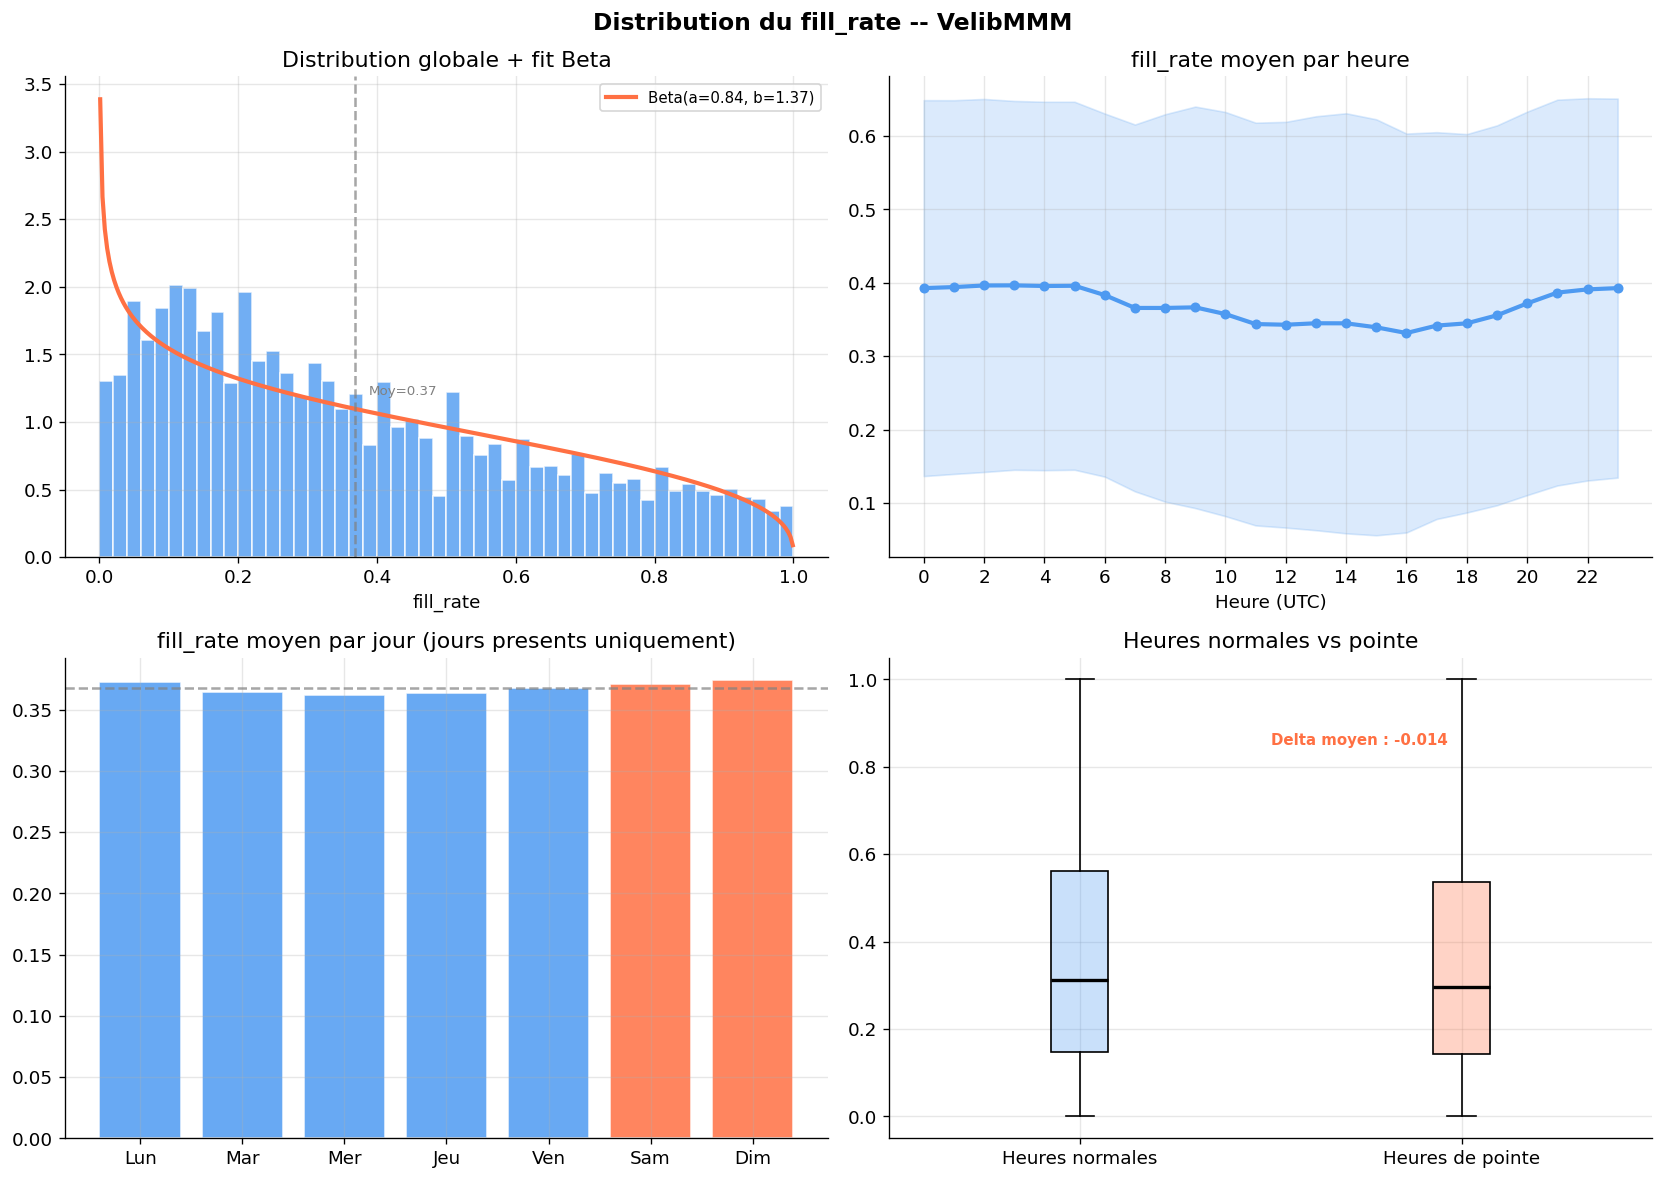

[OK] Figure sauvegardee
Fit Beta : alpha=0.838, beta=1.366
Mode=-0.800  |  Moyenne theorique=0.380
=> Ces parametres seront les priors de la Beta regression PyMC (notebook 03)


In [3]:
from scipy import stats as scipy_stats

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Distribution du fill_rate -- VelibMMM', fontsize=14, fontweight='bold')

# Distribution globale + fit Beta
ax = axes[0, 0]
ax.hist(df['fill_rate'], bins=50, color='#4E9AF1', alpha=0.8, edgecolor='white', density=True)
x = np.linspace(0.001, 0.999, 300)
a_beta, b_beta, _, _ = scipy_stats.beta.fit(df['fill_rate'].clip(0.001, 0.999), floc=0, fscale=1)
ax.plot(x, scipy_stats.beta.pdf(x, a_beta, b_beta), color='#FF7043', linewidth=2.5,
        label=f'Beta(a={a_beta:.2f}, b={b_beta:.2f})')
ax.axvline(x=df['fill_rate'].mean(), color='gray', linestyle='--', alpha=0.7)
mean_fr = df['fill_rate'].mean()
ax.annotate(f'Moy={mean_fr:.2f}', xy=(mean_fr+0.02, 1.2), fontsize=8, color='gray')
ax.set_title('Distribution globale + fit Beta')
ax.set_xlabel('fill_rate')
ax.legend(fontsize=9)

# Par heure
ax2 = axes[0, 1]
hourly = df.groupby('hour')['fill_rate'].agg(['mean','std'])
ax2.plot(hourly.index, hourly['mean'], color='#4E9AF1', linewidth=2.5, marker='o', markersize=5)
ax2.fill_between(hourly.index, hourly['mean']-hourly['std'],
                 hourly['mean']+hourly['std'], alpha=0.2, color='#4E9AF1')
ax2.set_title('fill_rate moyen par heure')
ax2.set_xlabel('Heure (UTC)')
ax2.set_xticks(range(0, 24, 2))

# Par jour -- labels dynamiques selon les jours presents dans les donnees
ax3 = axes[1, 0]
all_day_labels = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
daily = df.groupby('day_of_week')['fill_rate'].mean()
day_labels_present = [all_day_labels[i] for i in daily.index]
colors_d = ['#FF7043' if i >= 5 else '#4E9AF1' for i in daily.index]
ax3.bar(day_labels_present, daily.values, color=colors_d, alpha=0.85, edgecolor='white')
ax3.axhline(y=daily.mean(), color='gray', linestyle='--', alpha=0.7)
ax3.set_title('fill_rate moyen par jour (jours presents uniquement)')

# Rush vs normal
ax4 = axes[1, 1]
rush_hours = [7, 8, 9, 17, 18, 19]
data_rush  = df[df['hour'].isin(rush_hours)]['fill_rate'].values
data_other = df[~df['hour'].isin(rush_hours)]['fill_rate'].values
if len(data_rush) > 0 and len(data_other) > 0:
    bp = ax4.boxplot([data_other, data_rush], patch_artist=True,
                     labels=['Heures normales','Heures de pointe'],
                     medianprops={'color':'black','linewidth':2})
    bp['boxes'][0].set_facecolor('#4E9AF14D')
    bp['boxes'][1].set_facecolor('#FF70434D')
    diff = data_rush.mean() - data_other.mean()
    diff_str = f'{diff:+.3f}'
    ax4.annotate(f'Delta moyen : {diff_str}', xy=(1.5, 0.85),
                 fontsize=9, color='#FF7043', fontweight='bold')
else:
    ax4.text(0.5, 0.5, 'Pas assez de donnees', ha='center', transform=ax4.transAxes)
ax4.set_title('Heures normales vs pointe')

plt.tight_layout()
plt.savefig(str(FIG_DIR / '01_fillrate_distribution.png'), bbox_inches='tight', dpi=150)
plt.show()
print('[OK] Figure sauvegardee')
mode_val = (a_beta-1)/(a_beta+b_beta-2)
mean_val = a_beta/(a_beta+b_beta)
print(f'Fit Beta : alpha={a_beta:.3f}, beta={b_beta:.3f}')
print(f'Mode={mode_val:.3f}  |  Moyenne theorique={mean_val:.3f}')
print(f'=> Ces parametres seront les priors de la Beta regression PyMC (notebook 03)')

## 5. Patterns temporels -- le signal de drainage

On cherche les **patterns de drainage** -- les moments ou les stations se vident.
Ce sont ces patterns qu'on va capturer avec l'**adstock drainage** (EMA) dans le notebook 02.

**Analogie MMM :** le drainage = adstock des sorties de velos, exactement comme
l'adstock TV capture la memoire d'une campagne publicitaire.

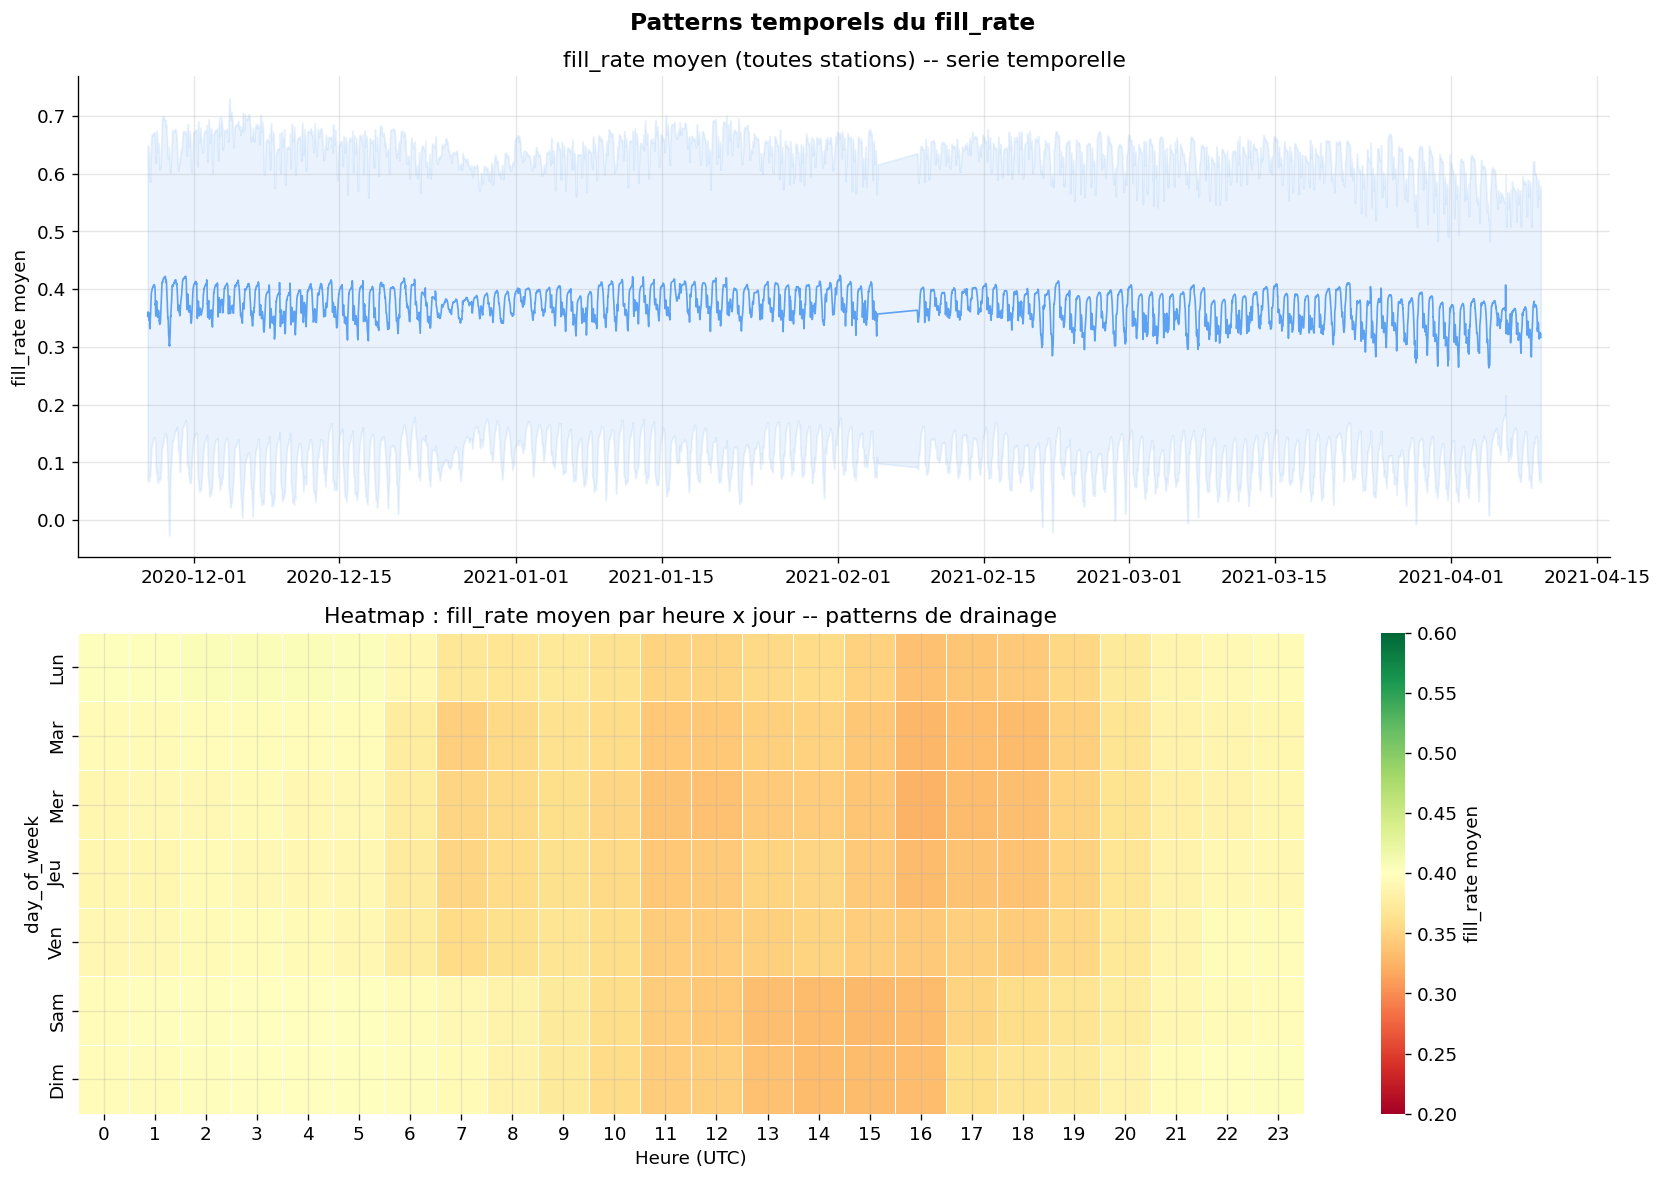

[OK] Figure sauvegardee


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle('Patterns temporels du fill_rate', fontsize=14, fontweight='bold')

# Serie temporelle globale
ax = axes[0]
ts_agg = df.groupby('ts_utc')['fill_rate'].agg(['mean','std']).reset_index()
ax.plot(ts_agg['ts_utc'], ts_agg['mean'], color='#4E9AF1', linewidth=1, alpha=0.9)
ax.fill_between(ts_agg['ts_utc'],
                ts_agg['mean'] - ts_agg['std'],
                ts_agg['mean'] + ts_agg['std'],
                alpha=0.12, color='#4E9AF1')
ax.set_title('fill_rate moyen (toutes stations) -- serie temporelle')
ax.set_ylabel('fill_rate moyen')

# Heatmap heure x jour
ax2 = axes[1]
pivot = df.groupby(['day_of_week','hour'])['fill_rate'].mean().unstack()
dow_labels = ['Lun','Mar','Mer','Jeu','Ven','Sam','Dim']
sns.heatmap(pivot, ax=ax2, cmap='RdYlGn', vmin=0.2, vmax=0.6,
            xticklabels=range(0,24), yticklabels=dow_labels,
            cbar_kws={'label':'fill_rate moyen'}, linewidths=0.3)
ax2.set_title('Heatmap : fill_rate moyen par heure x jour -- patterns de drainage')
ax2.set_xlabel('Heure (UTC)')

plt.tight_layout()
plt.savefig(str(FIG_DIR / '01_patterns_temporels.png'), bbox_inches='tight', dpi=150)
plt.show()
print('[OK] Figure sauvegardee')

## 6. Analyse par station

In [5]:
agg_dict = {'fill_rate': ['mean','std','min','max','count'], 'lat': 'first', 'lon': 'first'}
if 'name' in df.columns:
    agg_dict['name'] = 'first'

station_stats = df.groupby('station_id').agg(agg_dict)
col_names = ['fr_mean','fr_std','fr_min','fr_max','n_obs','lat','lon']
if 'name' in df.columns:
    col_names.append('name')
station_stats.columns = col_names
station_stats = station_stats.reset_index()
station_stats['cv'] = station_stats['fr_std'] / station_stats['fr_mean'].replace(0, np.nan)

print('=== Top 10 stations les plus variables (CV) ===')
top10 = station_stats.nlargest(10, 'cv')[['station_id','fr_mean','fr_std','cv','n_obs']]
print(top10.to_string(index=False))

n_empty = len(station_stats[station_stats['fr_mean'] < 0.1])
n_full  = len(station_stats[station_stats['fr_mean'] > 0.9])
n_total = len(station_stats)
print(f'\nStations souvent vides   (fr<0.1) : {n_empty} ({n_empty/n_total*100:.1f}%)')
print(f'Stations souvent pleines (fr>0.9) : {n_full}  ({n_full/n_total*100:.1f}%)')
print(f'Stations moderees        (reste)  : {n_total - n_empty - n_full}')

=== Top 10 stations les plus variables (CV) ===
                      station_id  fr_mean   fr_std       cv  n_obs
         Saint-Fargeau - Mortier 0.156342 0.193843 1.239862   7866
      Place du Maquis du Vercors 0.141732 0.175714 1.239757   7841
                 Mairie du 20ème 0.220968 0.272385 1.232691    738
    Solitaires - Place des Fêtes 0.157483 0.190120 1.207242   7866
Frères Flavien - Porte des Lilas 0.157552 0.187822 1.192130   7866
            Gambetta - Tourelles 0.197495 0.233739 1.183520   7823
    Place de la Division Leclerc 0.119712 0.141083 1.178519   7866
      Square des Saint-Simoniens 0.155606 0.181809 1.168388   7866
         Belleville - Télégraphe 0.128835 0.149414 1.159736   7866
         Pyrénées - Ménilmontant 0.169439 0.194048 1.145238   7866

Stations souvent vides   (fr<0.1) : 7 (0.5%)
Stations souvent pleines (fr>0.9) : 1  (0.1%)
Stations moderees        (reste)  : 1372


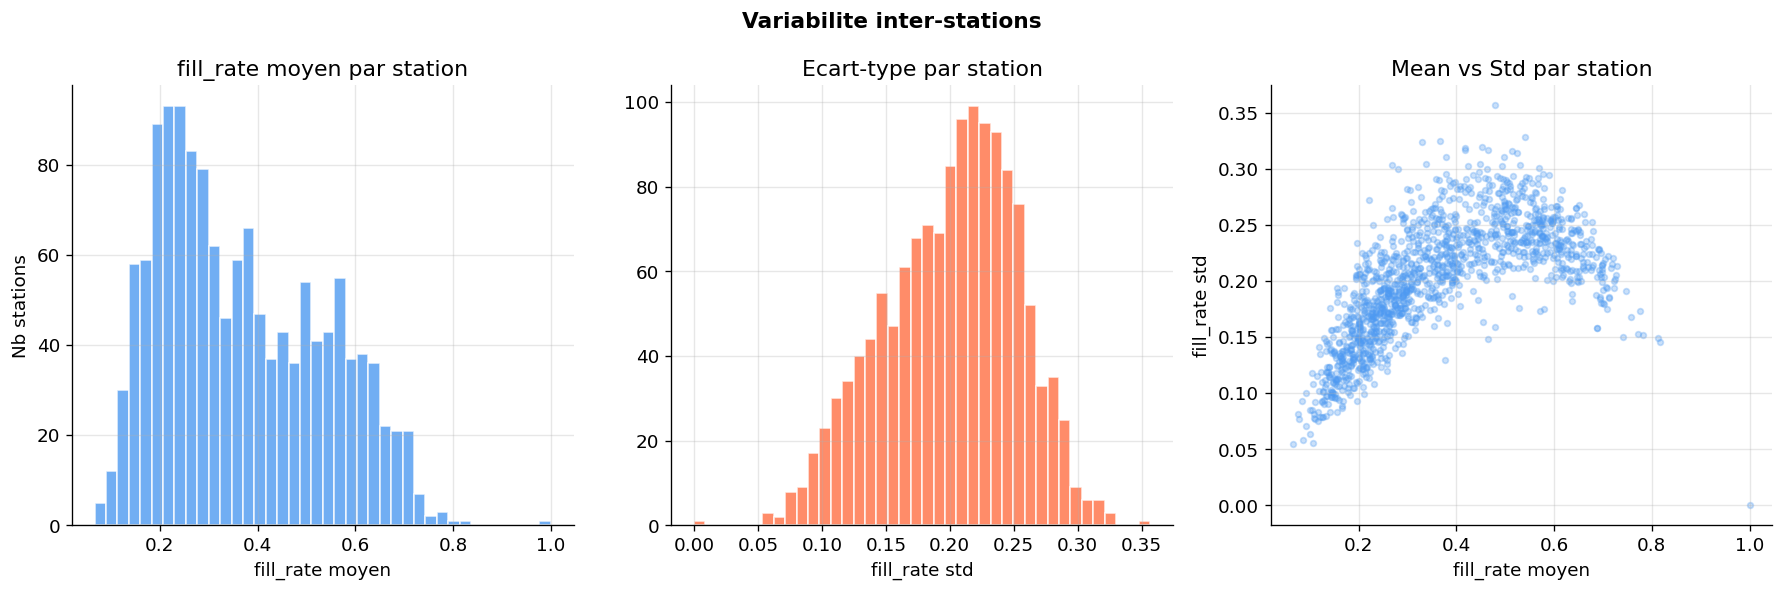

[OK] Figure sauvegardee


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Variabilite inter-stations', fontsize=13, fontweight='bold')

axes[0].hist(station_stats['fr_mean'], bins=40, color='#4E9AF1', alpha=0.8, edgecolor='white')
axes[0].set_title('fill_rate moyen par station')
axes[0].set_xlabel('fill_rate moyen')
axes[0].set_ylabel('Nb stations')

axes[1].hist(station_stats['fr_std'], bins=40, color='#FF7043', alpha=0.8, edgecolor='white')
axes[1].set_title('Ecart-type par station')
axes[1].set_xlabel('fill_rate std')

axes[2].scatter(station_stats['fr_mean'], station_stats['fr_std'],
                alpha=0.3, s=12, color='#4E9AF1')
axes[2].set_xlabel('fill_rate moyen')
axes[2].set_ylabel('fill_rate std')
axes[2].set_title('Mean vs Std par station')

plt.tight_layout()
plt.savefig(str(FIG_DIR / '01_variabilite_stations.png'), bbox_inches='tight', dpi=150)
plt.show()
print('[OK] Figure sauvegardee')

## 7. Carte interactive des stations

Chaque station est coloree selon son fill_rate moyen.
Les stations rouges sont souvent vides -- candidates prioritaires pour le modele de prediction.

In [8]:
try:
    import folium

    m = folium.Map(location=[48.8566, 2.3522], zoom_start=13, tiles='CartoDB positron')

    def color_fr(fr):
        if fr < 0.2:   return '#FF4444'
        elif fr < 0.4: return '#FF9944'
        elif fr < 0.6: return '#FFD700'
        elif fr < 0.8: return '#88CC44'
        else:          return '#22AA22'

    for _, row in station_stats.iterrows():
        if pd.isna(row['lat']) or pd.isna(row['lon']):
            continue
        nm = row['name'] if 'name' in station_stats.columns else str(row['station_id'])
        popup_txt = (
            f'<b>{nm}</b><br>ID: {row["station_id"]}<br>'
            f'fill_rate moy: {row["fr_mean"]:.2f}<br>'
            f'std: {row["fr_std"]:.2f}<br>n_obs: {int(row["n_obs"])}'
        )
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=4,
            color=color_fr(row['fr_mean']),
            fill=True, fill_opacity=0.75, weight=0.5,
            popup=folium.Popup(popup_txt, max_width=200)
        ).add_to(m)

    legend = (
        '<div style="position:fixed;bottom:30px;left:30px;z-index:1000;'
        'background:white;padding:10px;border-radius:8px;'
        'border:1px solid #ccc;font-size:12px;">'
        '<b>fill_rate moyen</b><br>'
        '<span style="color:#FF4444">&#9679;</span> &lt; 0.2 (vide)<br>'
        '<span style="color:#FF9944">&#9679;</span> 0.2 - 0.4<br>'
        '<span style="color:#FFD700">&#9679;</span> 0.4 - 0.6<br>'
        '<span style="color:#88CC44">&#9679;</span> 0.6 - 0.8<br>'
        '<span style="color:#22AA22">&#9679;</span> &gt; 0.8 (plein)</div>'
    )
    m.get_root().html.add_child(folium.Element(legend))
    map_path = str(FIG_DIR / '01_carte_stations.html')
    m.save(map_path)
    print(f'[OK] Carte : outputs/figures/01_carte_stations.html')
    print(f'     {len(station_stats)} stations cartographiees')
    m

except ImportError:
    print('[WARN] folium non installe -- pip install folium')

[OK] Carte : outputs/figures/01_carte_stations.html
     1380 stations cartographiees


## 8. Export du dataset nettoye

In [9]:
df.to_parquet(PROC_DIR / 'velib_clean.parquet', index=False)
station_stats.to_parquet(PROC_DIR / 'station_stats.parquet', index=False)

print(f'[OK] velib_clean.parquet   : {df.shape[0]:,} lignes x {df.shape[1]} colonnes')
print(f'[OK] station_stats.parquet : {len(station_stats)} stations')
print('\nColonnes exportees :')
for c in df.columns:
    print(f'  {c}')

[OK] velib_clean.parquet   : 10,769,262 lignes x 18 colonnes
[OK] station_stats.parquet : 1380 stations

Colonnes exportees :
  ts_utc
  capacity
  available_mechanical
  available_ebike
  name
  station_geo
  operative
  lat
  lon
  fill_rate
  station_id
  hour
  day_of_week
  date
  is_weekend
  is_rush
  is_night
  week


## 9. Synthese & insights cles

In [17]:
print('=' * 65)
print('  SYNTHESE EDA -- VelibMMM')
print('=' * 65)

n_stations = df['station_id'].nunique()
n_obs      = len(df)
fr_mean_s  = df['fill_rate'].mean()
fr_std_s   = df['fill_rate'].std()
pct_empty  = (df['fill_rate'] < 0.1).mean() * 100
pct_full   = (df['fill_rate'] > 0.9).mean() * 100
d_min      = str(df['ts_utc'].min())[:10]
d_max      = str(df['ts_utc'].max())[:10]

rush_hours = [7, 8, 9, 17, 18, 19]
data_rush  = df[df['hour'].isin(rush_hours)]['fill_rate'].values
data_other = df[~df['hour'].isin(rush_hours)]['fill_rate'].values
rush_delta = data_rush.mean() - data_other.mean() if len(data_rush) > 0 else 0

print(f'DONNEES')
print(f'  Source         : data/external/velib_history/historique_stations.csv')
print(f'  Stations       : {n_stations}')
print(f'  Observations   : {n_obs:,}')
print(f'  Periode        : {d_min} -- {d_max}')
print()
print(f'FILL_RATE (variable reponse)')
print(f'  Moyenne        : {fr_mean_s:.3f}')
print(f'  Ecart-type     : {fr_std_s:.3f}')
print(f'  Stations vides (<0.1)  : {pct_empty:.1f}%')
print(f'  Stations pleines (>0.9): {pct_full:.1f}%')
print()
print(f'PATTERNS TEMPORELS')
rush_delta_str = f'{rush_delta:+.3f}'
print(f'  Rush vs normal : delta {rush_delta_str}')
print()
print('PROCHAINE ETAPE --> Notebook 02 : Feature engineering')
print('  - Target      : fill_rate(t+30min) par station')
print('  - Adstock     : EMA du drainage')
print('  - Features    : hour_sin/cos, is_rush, is_weekend')
print('  - Voisinage   : fill_rate moyen des N stations proches')
print('=' * 65)

  SYNTHESE EDA -- VelibMMM
DONNEES
  Snapshots GBFS locaux  : 147
  Stations               : 1485
  Observations           : 218,151
  Periode                : 2025-11-10 -- 2025-11-13

FILL_RATE (variable reponse)
  Moyenne                : 0.388
  Ecart-type             : 0.286
  Fit Beta               : alpha=0.71, beta=1.06
  Stations vides (<0.1)  : 17.1%
  Stations pleines (>0.9): 6.1%

PATTERNS TEMPORELS
  Rush vs normal         : delta -0.016
  Heatmap jour x heure   : patterns de drainage clairs

PROCHAINE ETAPE --> Notebook 02 : Feature engineering
  - Target      : fill_rate(t+30min) par station
  - Adstock     : EMA du drainage (analogie adstock TV)
  - Features    : hour_sin/cos, is_rush, is_weekend, rain
  - Voisinage   : drainage moyen des N stations proches
  - MCMC (NB 03): Beta regression bayesienne avec PyMC
